# ECT Sensor – Exploratory Data Analysis

Explores the COMSOL-simulated EM sensor dataset.  
Each row is one combination of **relative permeability** (μr), **resistivity** (ρ), and **excitation frequency**.  
The two receiver coils (coil 2, coil 3) return complex mutual-inductance values; their difference gives the differential (gradiometer) signal used for inversion.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedFormatter

## 1. Load Data

Raw output from COMSOL exported to Excel. `header=4` skips the first four rows of COMSOL metadata so pandas reads the correct column-name row.

In [3]:
data = pd.read_excel(r"d:\Study\Uni\ect-inversion\data\raw\em_sensor_data.xlsx", header=4)
data.head()

,% MP,res,freq (Hz),real(mf.VCoil_2/(mf.ICoil_1*mf.omega*1j)) (H),imag(mf.VCoil_2/(mf.ICoil_1*mf.omega*1j)) (H),real(mf.VCoil_3/(mf.ICoil_1*mf.omega*1j)) (H),imag(mf.VCoil_3/(mf.ICoil_1*mf.omega*1j)) (H)
0,50,2.000000e-07,375,0.000582,-0.000002,0.000662,-0.000100
1,50,2.000000e-07,750,0.000584,0.000011,0.000603,-0.000167
2,50,2.000000e-07,1500,0.000602,0.000019,0.000480,-0.000209
3,50,2.000000e-07,3000,0.000622,0.000003,0.000359,-0.000172
4,50,2.000000e-07,6000,0.000621,-0.000030,0.000304,-0.000121


## 2. Rename Columns

COMSOL exports verbose expression strings as column headers. Rename to short, readable names used throughout the rest of the notebook.

In [4]:
# Rename COMSOL expression columns to concise labels.
# Column order matches the Excel export:
#   % MP  →  permeability (μr, relative)
#   res   →  resistivity  (ρ, Ω·m)
#   freq  →  frequency    (Hz)
#   real/imag of VCoil_2 / (ICoil_1 * ω * j)  →  coil2 mutual inductance components (H)
#   real/imag of VCoil_3 / (ICoil_1 * ω * j)  →  coil3 mutual inductance components (H)
data.columns = ['permeability', 'resistivity', 'frequency',
                'coil2_real', 'coil2_imag',
                'coil3_real', 'coil3_imag']
print(data.columns)
print(data.head())
print(data.shape)

Index(['permeability', 'resistivity', 'frequency', 'coil2_real', 'coil2_imag',
       'coil3_real', 'coil3_imag'],
      dtype='str')
   permeability   resistivity  frequency  coil2_real  coil2_imag  coil3_real  \
0            50  2.000000e-07        375    0.000582   -0.000002    0.000662   
1            50  2.000000e-07        750    0.000584    0.000011    0.000603   
2            50  2.000000e-07       1500    0.000602    0.000019    0.000480   
3            50  2.000000e-07       3000    0.000622    0.000003    0.000359   
4            50  2.000000e-07       6000    0.000621   -0.000030    0.000304   

   coil3_imag  
0   -0.000100  
1   -0.000167  
2   -0.000209  
3   -0.000172  
4   -0.000121  
(440, 7)


## 3. Differential (Gradiometer) Inductance

The sensor uses a gradiometer configuration: coil 2 and coil 3 are wound in opposition so that the common-mode background signal cancels.  
Subtracting coil 3 from coil 2 gives the net differential mutual inductance **H**, whose real and imaginary parts carry the material response.  
The sign of H depends on coil orientation in the COMSOL model; if the mean is negative the sign is flipped to match physical convention.

In [5]:
# Differential mutual inductance: H = coil2 - coil3
# Both the real and imaginary parts are differenced independently.
data['H_real'] = data['coil2_real'] - data['coil3_real']
data['H_imag'] = data['coil2_imag'] - data['coil3_imag']

# COMSOL coil orientation can produce an overall sign flip relative to
# the physical measurement convention. If the majority of H_real values
# are negative, negate the whole column so downstream plots are intuitive.
if data['H_real'].mean() < 0:
    data['H_real'] = -data['H_real']
if data['H_imag'].mean() < 0:
    data['H_imag'] = -data['H_imag']

print(data[['frequency', 'H_real', 'H_imag']].head(10))

   frequency    H_real    H_imag
0        375 -0.000079  0.000097
1        750 -0.000018  0.000178
2       1500  0.000122  0.000228
3       3000  0.000263  0.000175
4       6000  0.000318  0.000091
5      12000  0.000324  0.000041
6      24000  0.000325  0.000023
7      48000  0.000333  0.000011
8        375 -0.000069  0.000098
9        750 -0.000010  0.000177


## 4. Visualise Inductance vs Frequency

Four subplots in a 2×2 grid:
- **Top row** — fix resistivity at its lowest value, vary permeability across all simulated μr values.  
- **Bottom row** — fix permeability at its lowest value, vary resistivity across all simulated ρ values.  
- **Left column** — real part of H (in phase with excitation; linked to permeability).  
- **Right column** — imaginary part of H (90° out of phase; linked to eddy-current losses / conductivity).  

Frequency axis is logarithmic to span the full 375 Hz – 48 kHz sweep.

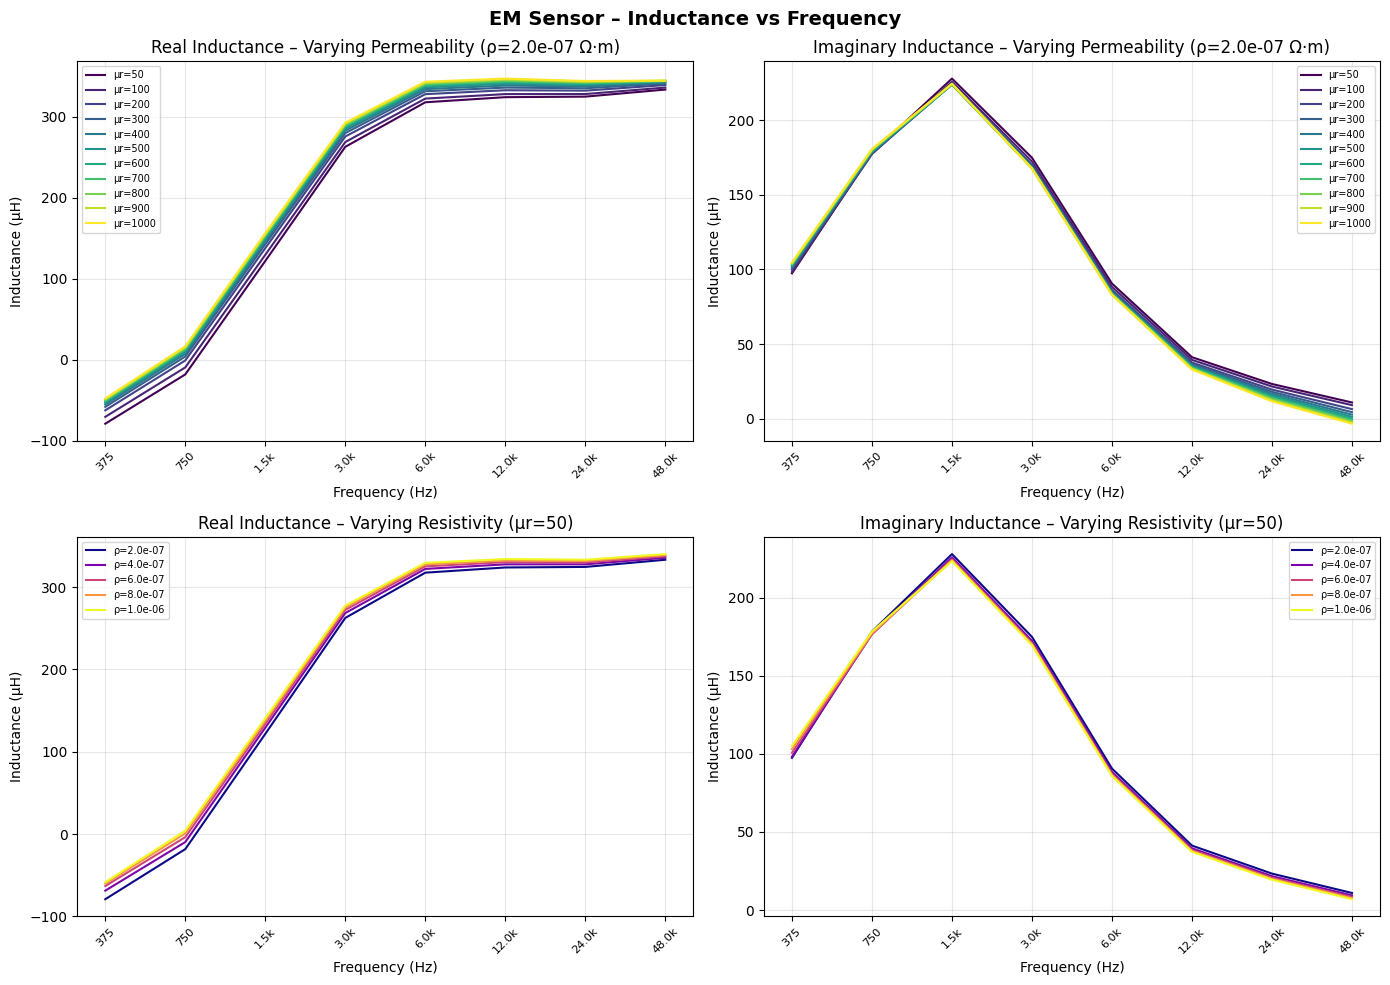

In [6]:
# Sorted unique parameter values across the simulation sweep
permeabilities = sorted(data['permeability'].unique())
resistivities  = sorted(data['resistivity'].unique())

# Choose fixed values for the "vary-one" subplots (lowest value in each sweep)
res_fixed  = resistivities[0]
perm_fixed = permeabilities[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EM Sensor – Inductance vs Frequency', fontsize=14, fontweight='bold')

# --- Top row: vary permeability, fix resistivity ---
# Isolate rows with the fixed resistivity, then loop over all μr values.
subset1 = data[data['resistivity'] == res_fixed]
colors1  = plt.get_cmap('viridis')(np.linspace(0, 1, len(permeabilities)))

for i, perm in enumerate(permeabilities):
    g = subset1[subset1['permeability'] == perm].sort_values('frequency')
    # Scale H from H to μH for readability
    axes[0, 0].plot(g['frequency'], g['H_real'] * 1e6, color=colors1[i], label=f'μr={int(perm)}')
    axes[0, 1].plot(g['frequency'], g['H_imag'] * 1e6, color=colors1[i], label=f'μr={int(perm)}')

axes[0, 0].set_title(f'Real Inductance – Varying Permeability (ρ={res_fixed:.1e} Ω·m)')
axes[0, 1].set_title(f'Imaginary Inductance – Varying Permeability (ρ={res_fixed:.1e} Ω·m)')

# --- Bottom row: vary resistivity, fix permeability ---
subset2 = data[data['permeability'] == perm_fixed]
colors2  = plt.get_cmap('plasma')(np.linspace(0, 1, len(resistivities)))

for i, res in enumerate(resistivities):
    g = subset2[subset2['resistivity'] == res].sort_values('frequency')
    axes[1, 0].plot(g['frequency'], g['H_real'] * 1e6, color=colors2[i], label=f'ρ={res:.1e}')
    axes[1, 1].plot(g['frequency'], g['H_imag'] * 1e6, color=colors2[i], label=f'ρ={res:.1e}')

axes[1, 0].set_title(f'Real Inductance – Varying Resistivity (μr={int(perm_fixed)})')
axes[1, 1].set_title(f'Imaginary Inductance – Varying Resistivity (μr={int(perm_fixed)})')

# --- Shared formatting ---
# Use the exact simulated frequencies as x-ticks on a log scale.
freq_ticks  = sorted(data['frequency'].unique())
freq_labels = [f'{f/1000:.1f}k' if f >= 1000 else str(int(f)) for f in freq_ticks]

for ax in axes.flat:
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Inductance (μH)')
    ax.legend(fontsize=7)
    ax.set_xscale('log')
    ax.set_xticks(freq_ticks)
    ax.set_xticklabels(freq_labels, rotation=45, fontsize=8)
    ax.get_xaxis().set_major_formatter(FixedFormatter(freq_labels))
    ax.minorticks_off()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('inductance_plots.png', dpi=150, bbox_inches='tight')
plt.show()